## Neural Network Regression with TensorFlow

There are many deffinitions for a regression problem but in our case, we are going to simplify it: predicting a numerical variable based on some other combination of variables, even shorter... predicting a number. 

Problems that one can solve with Regression:
1. How much will a house sell for?
2. How many peaple will buy an app?
3. How much will my health insurance be?
4. How mush should I save each week for fuel?
5. Predict the corners of where a bounding box should be for object detection problems. 

Regression analysis: Check this link from wikipedia for better understanding of Regression Analysis. <a>https://en.wikipedia.org/wiki/Regression_analysis</a>

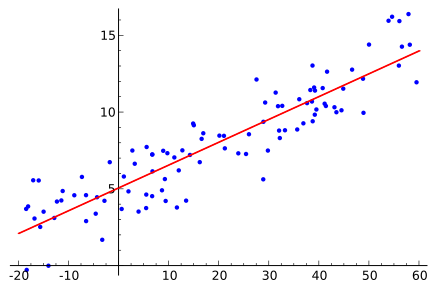

In [4]:
# Import TensorFlow library
import tensorflow as tf
# Check the TensorFlow version
print(tf.__version__)
# Check the available "GPU"
tf.config.list_physical_devices("GPU")

2.7.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## Creating some data to view and fit

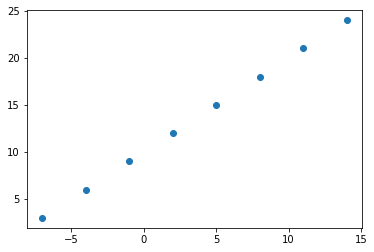

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Create the features (Independant Variable)
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels (Dependant Variable)
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize the data
plt.scatter(X, y)

In [7]:
y == X + 10 

array([ True,  True,  True,  True,  True,  True,  True,  True])

## Input and Output shapes



In [9]:
# Create demo tensor for our housing price prediction problem

house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [12]:
X[0], y[0]

(-7.0, 3.0)

In [13]:
X[1], y[1]

(-4.0, 6.0)

In [11]:
input_shape = X.shape
output_shape = y.shape
input_shape, output_shape

((8,), (8,))

In [14]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [18]:
X[0].ndim # It has no shape (rank 0 tensor)

0

In [29]:
# Turn our NumPy array into tensors with dtype float 32, the dtype is float64 by default
X = tf.cast(tf.constant(X), dtype = tf.float32)
y = tf.cast(tf.constant(y), dtype = tf.float32)
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [20]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([]))

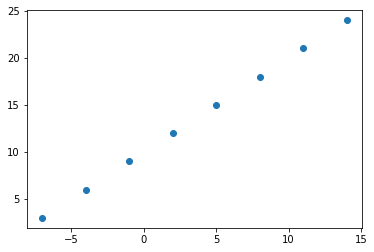

In [21]:
plt.scatter(X, y)

## Steps in modeling with TensorFlow

1. **Creating a model** - define the input and output layetrs, as well as the hidden layers of a deep leanring model. 
2. **Compiling a model** - define the loss function (in other words, the function which tells our model how wrong it is) and the optimizer (tells our model how to improve the patters its learning) and evaluation metrics (what we can use to interpret the perfromance of our model).
3. **Fitting a model** - letting the model try to find patterns between X and y (features and labels).

In [28]:
# Set random seed
tf.random.set_seed(42)

# 1. create a model using the Sequential API
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1) 
])

# 2. Compile the model
model.compile(loss = tf.keras.losses.mae, # mae is short for Mean Absolute Error)
              optimizer = tf.keras.optimizers.SGD(), #SGD is short for Stochastic Gradient Descent
              metrics = ['mae'])

# 3. Fit the Model
model.fit(tf.expand_dims(X, axis = -1), y, epochs = 5)

Epoch 1/5
1/1 [==============================] - 0s 329ms/step - loss: 11.5048 - mae: 11.5048
Epoch 2/5
1/1 [==============================] - 0s 6ms/step - loss: 11.3723 - mae: 11.3723
Epoch 3/5
1/1 [==============================] - 0s 12ms/step - loss: 11.2398 - mae: 11.2398
Epoch 4/5
1/1 [==============================] - 0s 7ms/step - loss: 11.1073 - mae: 11.1073
Epoch 5/5
1/1 [==============================] - 0s 8ms/step - loss: 10.9748 - mae: 10.9748


In [30]:
# Check out X and y
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [32]:
# Try and make prediction using our model
y_pred = model.predict([17.0])
y_pred

array([[12.716021]], dtype=float32)

In [33]:
y_pred + 11

array([[23.71602]], dtype=float32)